In [33]:
import os
from google.colab import drive

import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import math

! pip install keras_tuner
import keras_tuner as kt

! pip install visualkeras
import visualkeras

# Change these later
np.random.seed(1) # numpy seed
tf.random.set_seed(1) #tf seed

INPUT_SIZE=850 # looks like C macro lol

  Cloning https://github.com/paulgavrikov/visualkeras to /tmp/pip-req-build-an3q6z5r
  Running command git clone --filter=blob:none --quiet https://github.com/paulgavrikov/visualkeras /tmp/pip-req-build-an3q6z5r
  Resolved https://github.com/paulgavrikov/visualkeras to commit 71e2195b7eaed364ea493568cb1c8f2916af35f2
  Preparing metadata (setup.py) ... done


# Read in dataset

In [2]:
drive.mount('/content/drive')
base_dir = "/content/drive/MyDrive/team_software_project/"

Mounted at /content/drive


The ClassName and SampleIndex columns are redundant for our purposes. The dataset is split into 'windows' of 850 sample, roughly corresponding to 3.4 seconds for each window. Each window is labeled as either 1 (stroke), or 0 (not a stroke). Magnitude is the accelerometer reading

In [3]:
df = pd.read_csv(os.path.join(base_dir, "rowing_training.csv"))
df = df.drop(columns=["ClassName", "SampleIndex"])
df.head()

,WindowID,Label,Magnitude
0,0,1,-198.175892
1,0,1,-197.257224
2,0,1,-196.076210
3,0,1,-198.881628
4,0,1,-203.147633


Each window should have 850 datapoints, we will check below

In [4]:
counts = df.groupby("WindowID").size()
print(counts.unique())

[850]


Taking a look at the data for anything that needs cleaning

In [5]:
df.shape

(974950, 3)

In [6]:
df.describe(include="all")

,WindowID,Label,Magnitude
count,974950.000000,974950.000000,974950.000000
mean,573.000000,0.593723,-0.530922
std,331.110423,0.491138,189.077756
min,0.000000,0.000000,-502.283648
25%,286.000000,0.000000,-125.963654
50%,573.000000,1.000000,-31.475589
75%,860.000000,1.000000,55.871955
max,1146.000000,1.000000,876.323294


Nothing here looks out of the ordinary so no cleaning is required

Splitting the model in arrays for training

In [7]:
X = []
y = []

for window_id, group in df.groupby("WindowID"):
    magnitudes = group["Magnitude"].values
    label = group["Label"].iloc[0]   # all rows in window share label

    X.append(magnitudes)
    y.append(label)

X = np.array(X)
y = np.array(y)

There should be 1147 windows

In [8]:
print(X.shape)
print(y.shape)

(1147, 850)
(1147,)


Reshaping for convolutional layers

In [9]:
X = X.reshape((X.shape[0], X.shape[1], 1))

In [10]:
print(X.shape)

(1147, 850, 1)


Normalizing the data, this will make the training algorithms happy and it will allow for variance in terms of how powerful the rower's stroke is. For example, a very strong stroke compared to a weak stroke would both be detected as strokes

In [11]:
mean = X.mean()
std = X.std()

X = (X - mean) / std

In [12]:
X

array([[[-1.04531107],
        [-1.04045239],
        [-1.0342062 ],
        ...,
        [ 2.2602428 ],
        [ 2.2302799 ],
        [ 2.20728257]],

       [[ 0.755182  ],
        [ 0.71894242],
        [ 0.71669904],
        ...,
        [ 0.11472254],
        [ 0.10814999],
        [ 0.08605675]],

       [[-0.19839367],
        [-0.22310666],
        [-0.20478727],
        ...,
        [-1.20522307],
        [-1.2342177 ],
        [-1.26350222]],

       ...,

       [[-0.11547556],
        [-0.13728695],
        [-0.13208793],
        ...,
        [-0.57669457],
        [-0.5906374 ],
        [-0.59230641]],

       [[ 0.25993181],
        [ 0.26781699],
        [ 0.26871206],
        ...,
        [-0.38376704],
        [-0.3296396 ],
        [-0.20707415]],

       [[-0.23486103],
        [-0.2390868 ],
        [-0.24717993],
        ...,
        [-0.25874353],
        [-0.26289427],
        [-0.26471094]]])

Finally split into test and train arrays

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Make Model

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(INPUT_SIZE, 1)),
    tf.keras.layers.Conv1D(16, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(32, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 846, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 423, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 419, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 209, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6688)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       107,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,729 (428.63 KB)

 Trainable params: 109,729 (428.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(X_train, y_train, epochs=10)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.6224 - loss: 0.5440
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.8709 - loss: 0.3745
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9129 - loss: 0.2481
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.9007 - loss: 0.2249
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.9094 - loss: 0.1990
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9157 - loss: 0.1888
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.9217 - loss: 0.1773
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9315 - loss: 0.1692
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9351 - loss: 0.1586
Epoch 10/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9363 - loss: 0.1471


In [16]:
model.evaluate(X_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8604 - loss: 0.4468


[0.3847160339355469, 0.8826087117195129]

## Tuned model experiment

In [17]:
def create_model(hp):
  tuned_model = tf.keras.Sequential()
  tuned_model.add(tf.keras.Input(shape=(INPUT_SIZE, 1)))

  # Tuning hidden layers
  for i in range(hp.Int("num_conv_layers", 1, 2)):
    tuned_model.add(
        tf.keras.layers.Conv1D(
            filters=hp.Int(f"filters_{i}", min_value=8, max_value=64, step=8),
            kernel_size=5,
            activation='relu'
        )
    )
    tuned_model.add(tf.keras.layers.MaxPooling1D(2))


  tuned_model.add(tf.keras.layers.Flatten())
  tuned_model.add(tf.keras.layers.Dense(16, activation='relu'))
  tuned_model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

  tuned_model.compile(
      optimizer=tf.keras.optimizers.RMSprop(
          hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
      ),
      loss="binary_crossentropy",
      metrics=["accuracy"]
  )

  return tuned_model

In [18]:
tuner = kt.RandomSearch(
    create_model,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=1,
    directory=base_dir,
    project_name="gondolier"
)

Reloading Tuner from /content/drive/MyDrive/team_software_project/gondolier/tuner0.json


In [19]:
tuner.search(
    X_train, y_train,
    epochs=20,
    validation_split=0.2
)

In [20]:
best_model = tuner.get_best_models(1)[0]
best_model.summary()
best_model.count_params()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 846, 48)        │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 423, 48)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 419, 16)        │         3,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 209, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3344)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        53,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,681 (225.32 KB)

 Trainable params: 57,681 (225.32 KB)

 Non-trainable params: 0 (0.00 B)

57681

In [23]:
best_model.evaluate(X_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.8428 - loss: 0.4307


[0.36375629901885986, 0.8478260636329651]

Visual Representation of Model

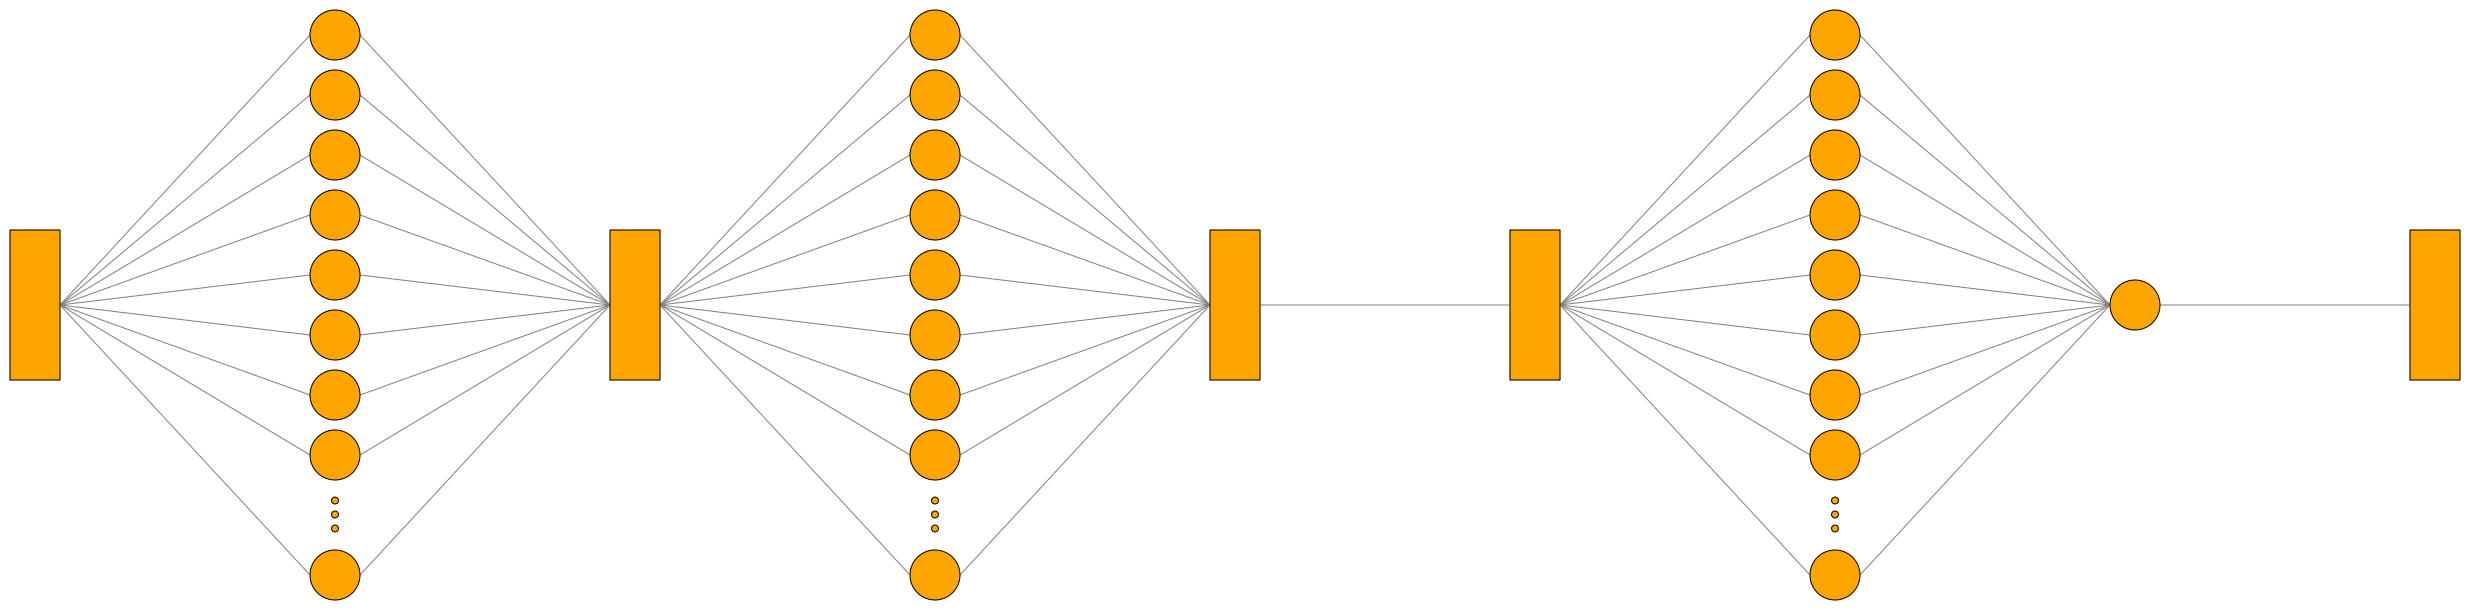

In [37]:
visualkeras.graph_view(best_model)

# Convert Model

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

Saved artifact at '/tmp/tmp9_9ua9ld'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 850, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136955588059088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136955141683536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136955141681808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136955141677008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136955141677584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136955141678928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136955141670096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136955141682768: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
with open(os.path.join(base_dir, "model.tflite"), 'wb') as f:
  f.write(tflite_model)